## Imports

In [10]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

print("Loading set")
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
print("Loaded")


Loading set
Loaded


## 2. MNIST laden

De MNIST-dataset bevat 70.000 handgeschreven cijfers (0-9).
Keras downloadt de data automatisch de eerste keer (~11 MB).

In [11]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print('=== Dataset geladen ===')
print('Trainingsset afbeeldingen :', X_train.shape)
print('Trainingsset labels       :', y_train.shape)
print('Testset afbeeldingen      :', X_test.shape)
print('Testset labels            :', y_test.shape)
print('Pixelwaarden: min =', X_train.min(), ', max =', X_train.max())
print('Unieke klassen:', np.unique(y_train))

=== Dataset geladen ===
Trainingsset afbeeldingen : (60000, 28, 28)
Trainingsset labels       : (60000,)
Testset afbeeldingen      : (10000, 28, 28)
Testset labels            : (10000,)
Pixelwaarden: min = 0 , max = 255
Unieke klassen: [0 1 2 3 4 5 6 7 8 9]


# **P2 Data exploratie**

## Taak 1: Visualisatie van een enkele afbeelding
    Kies een cijfer (maakt niet uit welke) uit de trainingsset.
    wat voor type is de datastructuur?
    Plot het cijfer met behulp van matplotlib zodat het er weer uitziet als een afbeelding.
    Draai de matrix met 90 graden en print het dan.

cijfer: 5
<class 'numpy.ndarray'>


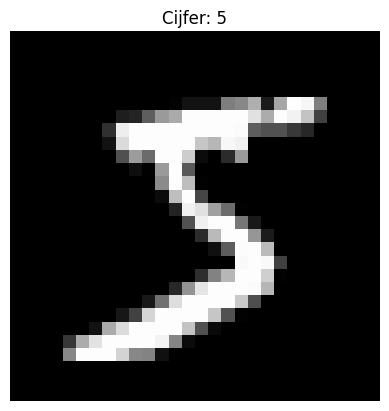

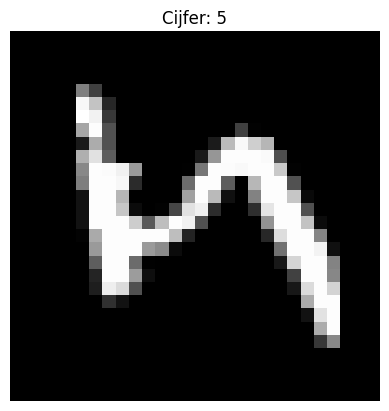

In [12]:
img = x_train[0]
label = y_train[0]
print("cijfer:", label)

print(type(img))

plt.imshow(img, cmap='gray')
plt.title(f'Cijfer: {label}')
plt.axis('off')
plt.show()

rotated_img = np.rot90(img)
# print(rotated_img)

plt.imshow(rotated_img, cmap='gray')
plt.title(f'Cijfer: {label}')
plt.axis('off')
plt.show()

In deze taak hebben we één afbeelding uit de MNIST dataset bekeken.
We hebben eerst het cijfer gekozen en het type van de datastructuur gecontroleerd, wat een NumPy array bleek te zijn.
Vervolgens hebben we de afbeelding geplot met matplotlib zodat deze er als een echte afbeelding uitziet.
Daarna hebben we de afbeelding 90 graden gedraaid en opnieuw geplot om te laten zien dat je de matrix kan bewerken

## Taak 2: Batchstatistieken

Loading set
Loaded
Totale gemiddelde pixelwaarde: 0.1307
Totale standaardafwijking pixelwaarde: 0.3081

Cijfer 0: gemiddelde = 0.1734, stdev = 0.3477
Cijfer 1: gemiddelde = 0.0760, stdev = 0.2443
Cijfer 2: gemiddelde = 0.1490, stdev = 0.3259
Cijfer 3: gemiddelde = 0.1415, stdev = 0.3179
Cijfer 4: gemiddelde = 0.1214, stdev = 0.2975
Cijfer 5: gemiddelde = 0.1287, stdev = 0.3036
Cijfer 6: gemiddelde = 0.1373, stdev = 0.3149
Cijfer 7: gemiddelde = 0.1145, stdev = 0.2917
Cijfer 8: gemiddelde = 0.1502, stdev = 0.3253
Cijfer 9: gemiddelde = 0.1226, stdev = 0.2986


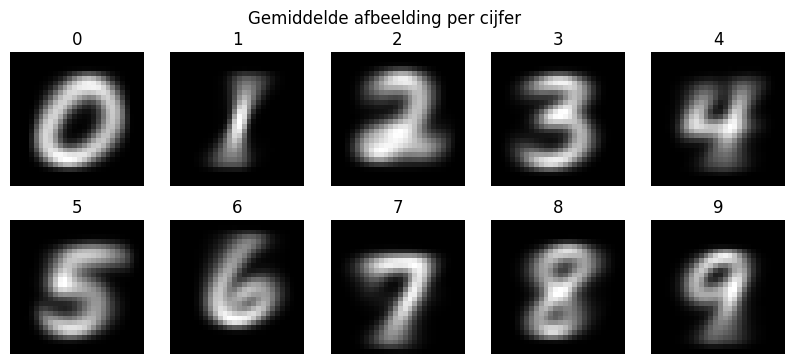

In [13]:
print("Loading set")
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
print("Loaded")

total_mean = np.mean(x_train)
total_std = np.std(x_train)
print(f"Totale gemiddelde pixelwaarde: {total_mean:.4f}")
print(f"Totale standaardafwijking pixelwaarde: {total_std:.4f}\n")

for digit in range(10):
    idx = np.where(y_train == digit)[0]
    digit_pixels = x_train[idx]
    mean_digit = np.mean(digit_pixels)
    std_digit = np.std(digit_pixels)
    print(f"Cijfer {digit}: gemiddelde = {mean_digit:.4f}, stdev = {std_digit:.4f}")

plt.figure(figsize=(10,4))
for digit in range(10):
    idx = np.where(y_train == digit)[0]
    mean_image = np.mean(x_train[idx], axis=0)
    plt.subplot(2,5,digit+1)
    plt.imshow(mean_image, cmap='gray')
    plt.title(f"{digit}")
    plt.axis('off')
plt.suptitle("Gemiddelde afbeelding per cijfer")
plt.show()

De gemiddelde pixelwaarde van de dataset is laag omdat de meeste pixels zwart zijn. Cijfers met meer wit oppervlak, zoals 0 of 8, hebben hogere gemiddelden dan smalle cijfers zoals 1. De gemiddelde afbeeldingen laten de typische vormen zien: het midden is lichter en de randen donkerder, en de wazige randen tonen de variatie in handschriften.

## Afbeelding met de grootste std

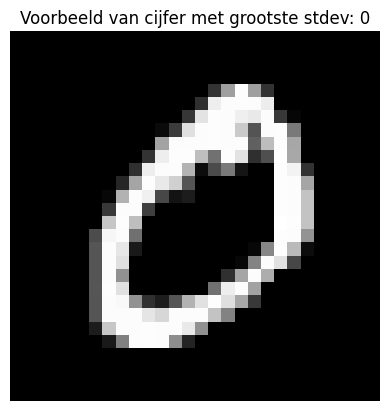

In [14]:
(x_train, y_train), _ = mnist.load_data()
x_train = x_train.astype('float32') / 255.0

digit_stds = {digit: np.std(x_train[np.where(y_train == digit)[0]]) for digit in range(10)}

max_std_digit = max(digit_stds, key=digit_stds.get)

example_image = x_train[np.where(y_train == max_std_digit)[0][0]]

# Toon de afbeelding
plt.imshow(example_image, cmap='gray')
plt.title(f"Voorbeeld van cijfer met grootste stdev: {max_std_digit}")
plt.axis('off')
plt.show()

## Experiment: Welke getal zie je?

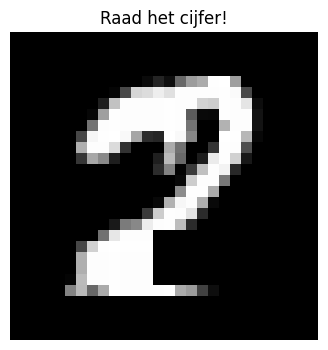

Het cijfer is 2


In [15]:
(x_train, y_train), _ = mnist.load_data()
x_train = x_train.astype('float32') / 255.0

idx = np.random.randint(0, len(x_train))
image = x_train[idx]
true_digit = y_train[idx]

hard_image = image.copy()

block_height = np.random.randint(5, 12)   
block_width = np.random.randint(5, 12)    
start_row = np.random.randint(0, 28 - block_height)
start_col = np.random.randint(0, 28 - block_width)
hard_image[start_row:start_row+block_height, start_col:start_col+block_width] = 0

hard_image = hard_image * np.random.uniform(0.5, 0.8)

# Toon de afbeelding
plt.figure(figsize=(4,4))
plt.imshow(hard_image, cmap='gray')
plt.axis('off')
plt.title("Raad het cijfer!")
plt.show()

print(f"Het cijfer is {true_digit}")

## Taak 3: Verschillende datastructuren onderzoek
    Laad de mnist database in verschillende datastructuren

    lijst
    queue
    dictionary
    Wat zijn typische acties die je zou willen doen met deze database?

    Als voorbeeld probeer het voor de volgende gevallen met deze verschillende datastructuren:

    Zoek eerste afbeelding van label 5
    voeg een nieuw element toe
    Loop door de gehele db
    optioneel: bedenk zelf iets
    Hoe kun je het goed opmeten (eg in bovenstaande voorbeeld krijg je nu mogelijk overal 0.0s omdat het allemaal snel gaat)

    Kies een lastige feature

    Voorbeeld:

    Zoek de eerste afbeelding van een even nummer groter dan 5

    Of zoek alle afbeeldingen waar de som van pixelwaarden > 10000

    Of zoek alle afbeeldingen met een specifieke combinatie van labels en pixelkenmerken

    Daardoor wordt het verschil tussen lijsten, queues en dictionaries veel zichtbaarder.


In [16]:
mnist_list = [(x_train[i], y_train[i]) for i in range(len(x_train))]

mnist_queue = [(x_train[i], y_train[i]) for i in range(len(x_train))]

mnist_dict = {i: (x_train[i], y_train[i]) for i in range(len(x_train))}

#List:
for img, label in mnist_list:
    if label == 5:
        first_img_label5 = img
        break
print("Eerste afbeelding met label 5 gevonden in lijst")

#Queue:
for img, label in mnist_queue:
    if label == 5:
        first_img_label5_queue = img
        break
print("Eerste afbeelding met label 5 gevonden in queue")

#Dictionary:
for key, (img, label) in mnist_dict.items():
    if label == 5:
        first_img_label5_dict = img
        break
print("Eerste afbeelding met label 5 gevonden in dictionary")


#List:
mnist_list.append((x_train[0], y_train[0]))
print("Nieuw element toegevoegd aan lijst")

#Queue:
mnist_queue.append((x_train[0], y_train[0]))
print("Nieuw element toegevoegd aan queue")

#Dictionary:
mnist_dict[len(mnist_dict)] = (x_train[0], y_train[0])
print("Nieuw element toegevoegd aan dictionary")

#Zo werkt de queue
removed_element = mnist_queue.pop(0)
print("Eerste element verwijderd uit queue")


#List, Queue:
for img, label in mnist_list:
    pass

#Dictionary:
for key, (img, label) in mnist_dict.items():
    pass

hard_feature_imgs = [img for img, label in mnist_list if img.sum() > 250]
print("Aantal afbeeldingen met pixel som > 250:", len(hard_feature_imgs))

Eerste afbeelding met label 5 gevonden in lijst
Eerste afbeelding met label 5 gevonden in queue
Eerste afbeelding met label 5 gevonden in dictionary
Nieuw element toegevoegd aan lijst
Nieuw element toegevoegd aan queue
Nieuw element toegevoegd aan dictionary
Eerste element verwijderd uit queue
Aantal afbeeldingen met pixel som > 250: 12


In deze taak hebben we de MNIST dataset in drie verschillende datastructuren gezet: een lijst, een queue (FIFO) en een dictionary.
We hebben laten zien hoe je een specifiek cijfer kunt vinden, een nieuw element kunt toevoegen, en door de hele dataset kunt lopen.
Daarnaast hebben we een lastige feature gezocht, namelijk alle afbeeldingen waarvan de som van de pixelwaarden groter is dan 10000.
Bij de queue hebben we laten zien hoe FIFO werkt door het eerste element eruit te halen.
Deze opdracht laat zien hoe je verschillende datastructuren kunt gebruiken en welke acties je er makkelijk mee kunt uitvoeren.